# XRD Batch Analysis to Technical Memo
### Same-material batch characterization · samdhole.github.io

---

## The Real-World Use Case

A characterization lab runs 8 samples of the same material from a process variation study (annealing temperatures, milling times, deposition conditions). Each XRD pattern needs to be peak-fit individually, the same reflection tracked across all 8 samples, and a summary memo delivered to the process engineer.

**Manual workflow:** open each pattern in JADE/HighScore/EVA, identify peaks by eye, fit profile functions, record FWHM and position into a spreadsheet, compute d-spacings and Scherrer sizes by hand, write the memo. **~4 hours for 8 samples.**

**This pipeline:** load → auto-detect → batch-fit → trend-track → memo. **~20 seconds.**

---

## Demo Dataset

8 simulated quartz patterns with systematic FWHM broadening (0.08° → 0.22°). Synthetic data lets us know exactly which 15 reflections should be detected (ICDD 00-046-1045 quartz). In production this would be 8 batches of one material under varying processing conditions.

| Step | Section | Output |
|------|---------|--------|
| 1 | Load batch | 8 XRDData objects |
| 2 | Visualize raw spectra | 2×4 grid |
| 3 | Single-sample walkthrough | DoG detection + ROI fits annotated |
| 4 | Batch fit | FitResult per sample (~1.5s each) |
| 5 | Summary table | Per-sample dominant peak |
| 6 | Per-peak table | All ~15 reflections × 8 samples (xrdfit-style) |
| 7 | Trend plot | Peak position + FWHM vs sample index |
| 8 | HTML memo | Single-file deliverable |

**Method:** Difference of Gaussians (xrfit-style) for auto-detect, per-peak ROI lmfit PseudoVoigt, Scherrer K=0.9 (Cu Kα λ=1.54056 Å)


## Step 1: Load XRD Batch

In [1]:
import sys, time, io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image

_nb_cwd = Path().resolve()
_repo_root = _nb_cwd.parent if _nb_cwd.name == "notebooks" else _nb_cwd
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from autoxrd.loader import XRDLoader
from autoxrd.fitter import XRDFitter
from autoxrd.analyzer import XRDAnalyzer
from autoxrd.reporter import HTMLReporter

DATA_DIR = _repo_root / "data" / "synthetic_quartz"
OUTPUT_DIR = _repo_root / "output" / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _inline_show(*args, **kwargs):
    fig = plt.gcf()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close("all")
plt.show = _inline_show

t0_total = time.perf_counter()

t0 = time.perf_counter()
samples = XRDLoader.load_directory(DATA_DIR)
load_time = time.perf_counter() - t0
print(f"Loaded {len(samples)} samples in {load_time:.3f}s")
for name, xrd in samples.items():
    n = len(xrd.df)
    lo, hi = xrd.df["two_theta"].min(), xrd.df["two_theta"].max()
    print(f"  {name:<25s} {n:5d} pts  lambda={xrd.wavelength:.5f} A  2theta: {lo:.1f}-{hi:.1f} deg")


Loaded 8 samples in 0.249s
  Quartz_Anneal_01           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_02           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_03           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_04           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_05           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_06           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_07           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg
  Quartz_Anneal_08           3500 pts  lambda=1.54056 A  2theta: 10.0-80.0 deg


## Step 2: Visualize Raw Spectra

Each pattern is the same quartz material at a different (simulated) annealing condition. The peaks are at the same 2θ positions across the batch, but their widths increase as grains coarsen.

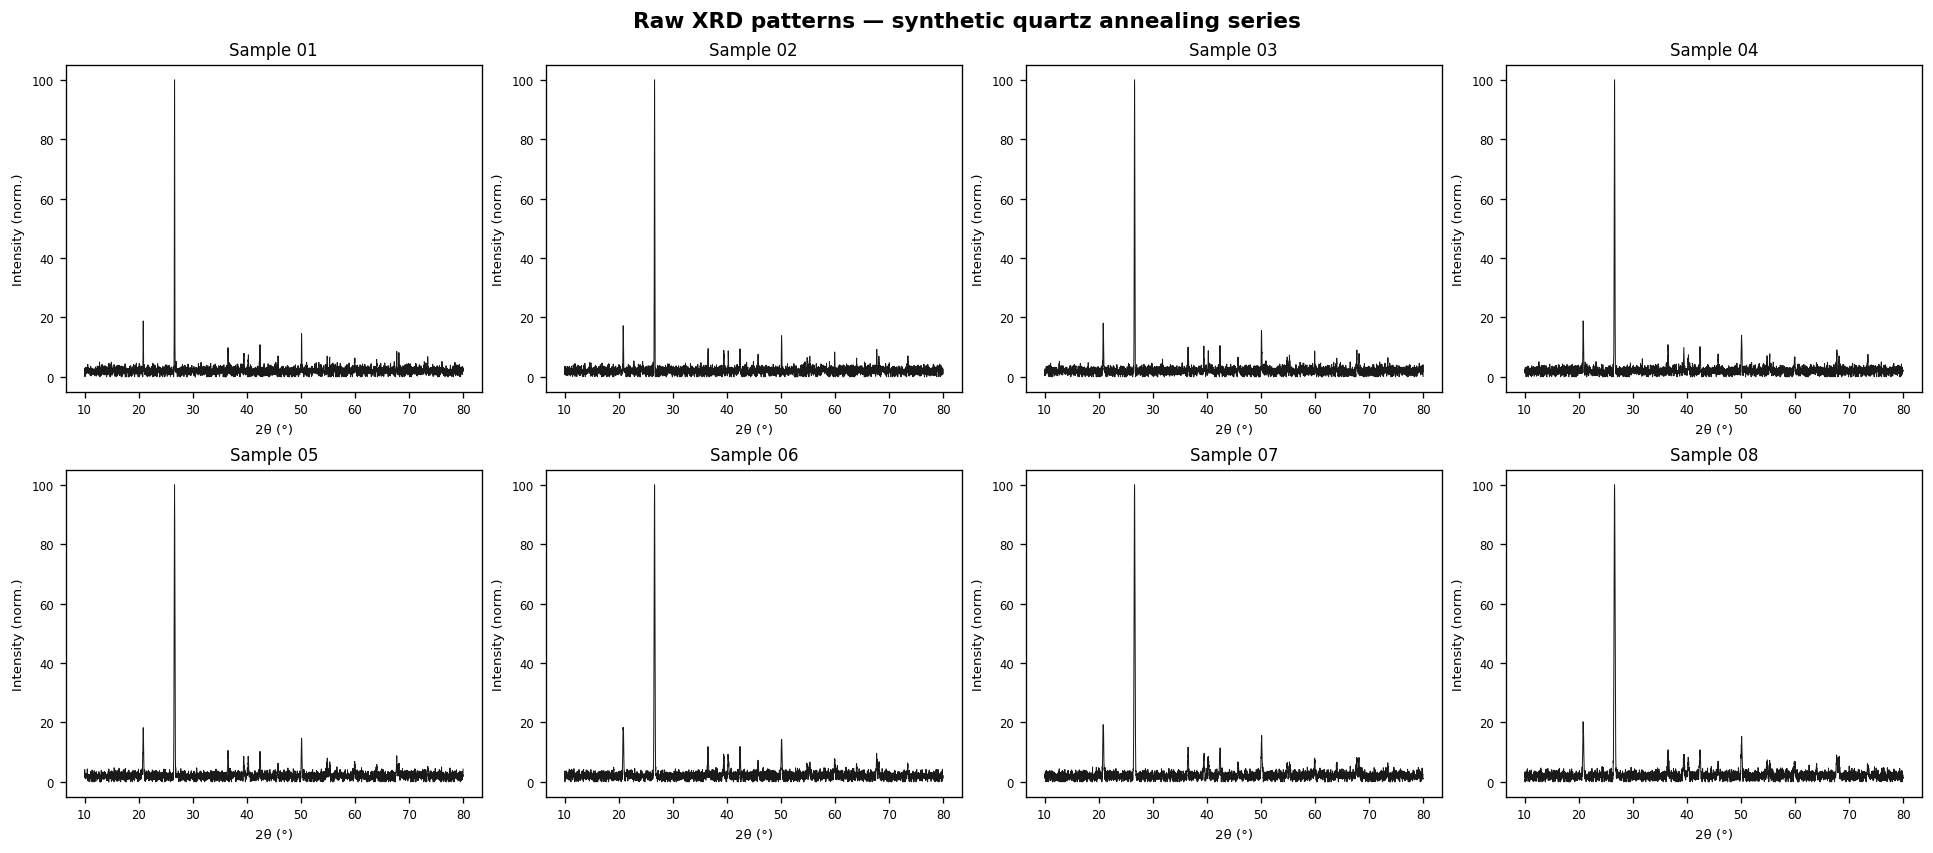

All 8 patterns share the same peak positions; FWHM increases left→right, top→bottom.


In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)
fig.suptitle("Raw XRD patterns — synthetic quartz annealing series",
             fontsize=13, fontweight="bold")
for ax, (name, xrd) in zip(axes.flat, samples.items()):
    ax.plot(xrd.df["two_theta"], xrd.df["intensity"], color="#1a1a1a", lw=0.6)
    label = name.replace("Quartz_Anneal_", "Sample ")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("2θ (°)", fontsize=8)
    ax.set_ylabel("Intensity (norm.)", fontsize=8)
    ax.tick_params(labelsize=7)
plt.show()
print("All 8 patterns share the same peak positions; FWHM increases left→right, top→bottom.")


## Step 3: Single-Sample Walkthrough — DoG Detection + ROI Fits

The fitter has two stages.

**Detect (Difference of Gaussians, after `xrfit`):** convolve the spectrum with a narrow Gaussian (preserves peaks, kills noise) and a wide Gaussian (approximates baseline). The bandpass `narrow − wide` isolates peaks against any baseline shape. Threshold = k×MAD(bandpass) on peak-free regions. No prominence knob to tune.

**Fit (per-peak ROI):** crop ±0.25° around each detected peak, fit a single PseudoVoigt + linear background. ~30 ms per peak vs minutes for global multi-peak fits. Quality filter rejects fits with FWHM<0.04°, R²<0.5, or amplitude<0.25.

Sample: Quartz_Anneal_04
DoG: σ_signal=2.0pts, σ_baseline=75.0pts
Bandpass noise (MAD): 0.304, threshold = 4.0σ = 1.214
DoG raw candidates: 38, kept after fit-quality filter: 14
Mean per-peak local R²: 0.8537


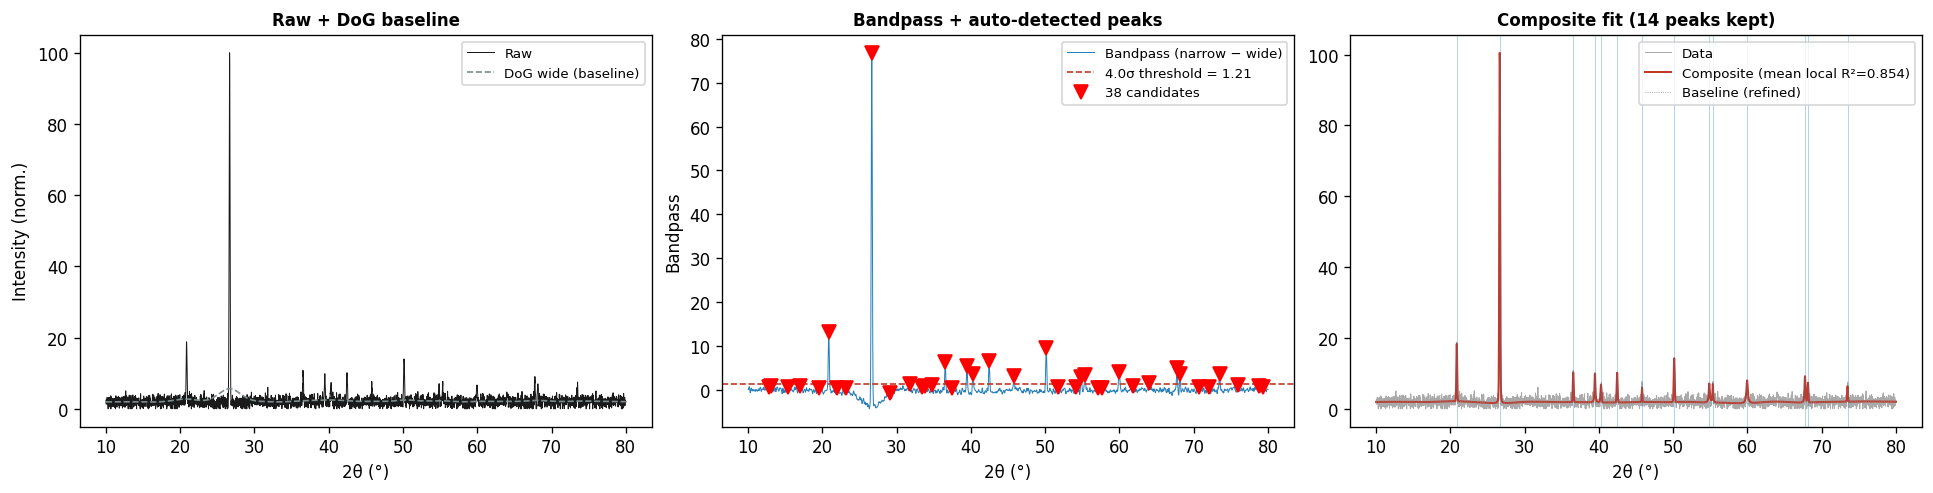

In [3]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# Pick sample 4 (mid-FWHM) for the walkthrough
demo_name = list(samples.keys())[3]
demo = samples[demo_name]
x = demo.df["two_theta"].values
y = demo.df["intensity"].values

# Replicate the fitter's DoG detection for visualization
fitter = XRDFitter()
dx = float(np.mean(np.diff(x)))
sig_signal = max(1.0, fitter.sigma_signal_deg / dx)
sig_baseline = max(sig_signal * 5.0, fitter.sigma_baseline_deg / dx)
y_signal = gaussian_filter1d(y, sigma=sig_signal)
y_baseline = gaussian_filter1d(y, sigma=sig_baseline)
bandpass = y_signal - y_baseline
low_half = bandpass[bandpass <= np.quantile(bandpass, 0.5)]
noise = float(np.median(np.abs(low_half - np.median(low_half))) / 0.6745)
threshold = fitter.k_sigma * noise

distance = max(1, int(fitter.MIN_SEPARATION_DEG / dx))
min_w = max(2, int(fitter.MIN_FWHM_DETECT_DEG / dx))
peak_idx, _ = find_peaks(bandpass, prominence=threshold, width=min_w, distance=distance)

# Run the actual fit on the same sample
result = fitter.fit_sample(demo)

print(f"Sample: {demo_name}")
print(f"DoG: σ_signal={sig_signal:.1f}pts, σ_baseline={sig_baseline:.1f}pts")
print(f"Bandpass noise (MAD): {noise:.3f}, threshold = {fitter.k_sigma}σ = {threshold:.3f}")
print(f"DoG raw candidates: {len(peak_idx)}, kept after fit-quality filter: {result.n_peaks}")
print(f"Mean per-peak local R²: {result.r_squared:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

# Panel 1: raw + DoG components
axes[0].plot(x, y, color="#1a1a1a", lw=0.6, label="Raw")
axes[0].plot(x, y_baseline, color="#7f8c8d", lw=1.0, ls="--", label="DoG wide (baseline)")
axes[0].set_title("Raw + DoG baseline", fontsize=10, fontweight="bold")
axes[0].set_xlabel("2θ (°)"); axes[0].set_ylabel("Intensity (norm.)")
axes[0].legend(fontsize=8)

# Panel 2: bandpass + detected peaks
axes[1].plot(x, bandpass, color="#2980b9", lw=0.6, label="Bandpass (narrow − wide)")
axes[1].axhline(threshold, color="#c0392b", ls="--", lw=1.0,
                label=f"{fitter.k_sigma}σ threshold = {threshold:.2f}")
axes[1].plot(x[peak_idx], bandpass[peak_idx], "rv", ms=8, label=f"{len(peak_idx)} candidates")
axes[1].set_title("Bandpass + auto-detected peaks", fontsize=10, fontweight="bold")
axes[1].set_xlabel("2θ (°)"); axes[1].set_ylabel("Bandpass")
axes[1].legend(fontsize=8)

# Panel 3: composite fit
axes[2].plot(result.x, result.y, color="#aaa", lw=0.6, label="Data")
axes[2].plot(result.x, result.y_fit, color="#c0392b", lw=1.2, label=f"Composite (mean local R²={result.r_squared:.3f})")
axes[2].plot(result.x, result.baseline, color="#7f8c8d", lw=0.5, ls=":", label="Baseline (refined)")
for p in result.all_peaks:
    axes[2].axvline(p["center"], color="#2980b9", lw=0.4, alpha=0.5)
axes[2].set_title(f"Composite fit ({result.n_peaks} peaks kept)", fontsize=10, fontweight="bold")
axes[2].set_xlabel("2θ (°)")
axes[2].legend(fontsize=8)

plt.show()


## Step 4: Batch Fit All 8 Samples

In [4]:
print("Running batch peak fitting...")
t0_fit = time.perf_counter()
fit_results = XRDFitter().fit_batch(samples, progress=True)
fit_time = time.perf_counter() - t0_fit
print(f"\nBatch complete: {len(fit_results)} samples fitted in {fit_time:.1f}s")
print(f"  Mean time per sample: {fit_time/len(fit_results)*1000:.0f} ms\n")
for name, fr in fit_results.items():
    label = name.replace("Quartz_Anneal_", "Sample ")
    print(f"  {label:<12s}  N_peaks={fr.n_peaks:2d}  R²={fr.r_squared:.4f}  dominant fwhm={fr.dominant_peak['fwhm']:.4f}")


Running batch peak fitting...


Fitting: 100%|██████████| 8/8 [00:13<00:00,  1.64s/sample]


Batch complete: 8 samples fitted in 13.1s
  Mean time per sample: 1643 ms

  Sample 01     N_peaks=15  R²=0.7852  dominant fwhm=0.0794
  Sample 02     N_peaks=16  R²=0.7923  dominant fwhm=0.0995
  Sample 03     N_peaks=15  R²=0.8131  dominant fwhm=0.1197
  Sample 04     N_peaks=14  R²=0.8537  dominant fwhm=0.1401
  Sample 05     N_peaks=15  R²=0.8117  dominant fwhm=0.1584
  Sample 06     N_peaks=16  R²=0.8157  dominant fwhm=0.1799
  Sample 07     N_peaks=15  R²=0.8391  dominant fwhm=0.2010
  Sample 08     N_peaks=16  R²=0.7759  dominant fwhm=0.2205


## Step 5: Per-Sample Summary Table

The dominant reflection (largest amplitude) for each sample. This is the top-level view a process engineer reads first.

In [5]:
summary = XRDAnalyzer.build_summary_table(fit_results)
summary = XRDAnalyzer.flag_outliers(summary)

display(
    summary[["Sample", "2θ (°)", "d-spacing (Å)", "FWHM (°)", "Crystallite Size (nm)", "R²", "Flag"]]
    .style
    .format({"2θ (°)": "{:.3f}", "d-spacing (Å)": "{:.4f}", "FWHM (°)": "{:.4f}",
             "Crystallite Size (nm)": "{:.1f}", "R²": "{:.4f}"})
    .apply(lambda col: ["background-color: #ffc0c0" if (isinstance(v, float) and v < XRDAnalyzer.POOR_FIT_R2_THRESHOLD) else ""
                       for v in col], subset=["R²"])
    .set_caption("Dominant peak per sample")
)


,Sample,2θ (°),d-spacing (Å),FWHM (°),Crystallite Size (nm),R²,Flag
0,Quartz_Anneal_01,26.650,3.3422,0.0794,102.8,0.7852,
1,Quartz_Anneal_02,26.650,3.3421,0.0995,82.1,0.7923,
2,Quartz_Anneal_03,26.650,3.3422,0.1197,68.2,0.8131,
3,Quartz_Anneal_04,26.650,3.3422,0.1401,58.3,0.8537,
4,Quartz_Anneal_05,26.650,3.3422,0.1584,51.5,0.8117,
5,Quartz_Anneal_06,26.650,3.3422,0.1799,45.4,0.8157,
6,Quartz_Anneal_07,26.650,3.3422,0.2010,40.6,0.8391,
7,Quartz_Anneal_08,26.650,3.3422,0.2205,37.0,0.7759,


## Step 6: Per-Peak Parameter Table

All ~15 quartz reflections detected in each sample. This is the table xrdfit produces — center, d-spacing, FWHM, Scherrer crystallite size, relative intensity, η — but xrdfit requires the user to pre-specify peak ranges. Here it's automatic.

In [6]:
peak_table = XRDAnalyzer.build_peak_table(fit_results)
print(f"Peak table: {len(peak_table)} rows ({len(peak_table) // len(fit_results)} avg peaks/sample)\n")

display(
    peak_table.head(20).style
    .format({"2θ (°)": "{:.3f}", "d-spacing (Å)": "{:.4f}", "FWHM (°)": "{:.4f}",
             "Crystallite Size (nm)": "{:.1f}", "Rel. Intensity (%)": "{:.1f}", "η": "{:.3f}"})
    .set_caption("Per-peak parameters (first 20 rows; full table embedded in HTML memo)")
)


Peak table: 122 rows (15 avg peaks/sample)



,Sample,Phase,Peak #,2θ (°),d-spacing (Å),FWHM (°),Crystallite Size (nm),Rel. Intensity (%),η
0,Quartz_Anneal_01,Quartz_Anneal_01,1,20.861,4.2547,0.0744,108.6,16.2,0.000
1,Quartz_Anneal_01,Quartz_Anneal_01,2,26.650,3.3422,0.0794,102.8,100.0,0.000
2,Quartz_Anneal_01,Quartz_Anneal_01,3,36.536,2.4573,0.0740,113.1,7.0,0.000
3,Quartz_Anneal_01,Quartz_Anneal_01,4,39.470,2.2812,0.0914,92.3,7.3,0.000
4,Quartz_Anneal_01,Quartz_Anneal_01,5,40.291,2.2366,0.0969,87.3,5.9,0.000
5,Quartz_Anneal_01,Quartz_Anneal_01,6,42.452,2.1276,0.0757,112.6,8.5,0.000
6,Quartz_Anneal_01,Quartz_Anneal_01,7,45.785,1.9801,0.0484,178.2,4.8,1.000
7,Quartz_Anneal_01,Quartz_Anneal_01,8,50.141,1.8178,0.0795,110.3,12.7,0.000
8,Quartz_Anneal_01,Quartz_Anneal_01,9,54.876,1.6717,0.0518,172.7,5.3,1.000
9,Quartz_Anneal_01,Quartz_Anneal_01,10,55.323,1.6592,0.0635,141.3,4.0,0.000


## Step 7: Peak Trend Tracking Across Batch

For a same-material batch, the value-add is tracking how each peak family evolves. Position drift indicates lattice strain or composition change. FWHM increase indicates grain refinement, micro-strain, or instrument shift. The synthetic data has perfect peak positions and monotonically increasing FWHM — the trend plot should reflect that.

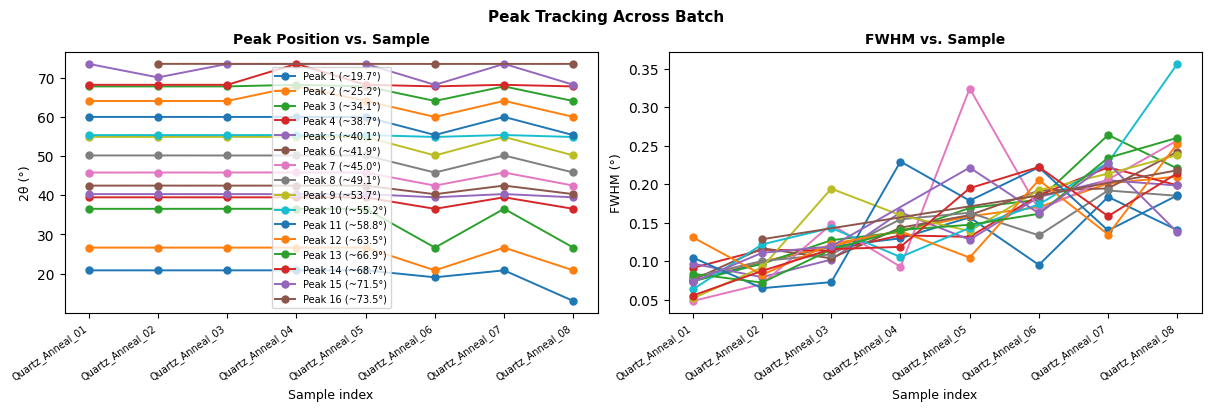

Position lines flat ⇒ no lattice change. FWHM lines monotonic ⇒ systematic broadening — exactly what the synthetic data encodes.


In [7]:
sample_order = list(fit_results.keys())
trend_b64 = HTMLReporter.build_trend_figure(peak_table, sample_order)
display(Image(data=__import__("base64").b64decode(trend_b64)))
print("Position lines flat ⇒ no lattice change. FWHM lines monotonic ⇒ systematic broadening — exactly what the synthetic data encodes.")


## Step 7b: Linear Trend Models

Fitting peak position and FWHM as linear functions of sample index quantifies what the scatter plot suggests visually. The slope tells you the rate of change per sample; R² tells you how well the linear model fits.

Linear trend models for 16 peak families:



,Peak #,Center (°),N_obs,Position slope (°/sample),Position R²,FWHM slope (°/sample),FWHM R²
0,1,19.661,8,-0.71533,0.4071,0.01003,0.4755
1,2,25.201,8,-0.68996,0.3969,0.01895,0.9938
2,3,34.068,8,-1.17666,0.3963,0.02442,0.8975
3,4,38.733,8,-0.34955,0.3971,0.01786,0.8700
4,5,40.084,8,-0.09598,0.3897,0.01843,0.8368
5,6,41.907,8,-0.25860,0.3945,0.02183,0.9527
6,7,44.956,8,-0.39694,0.3963,0.02888,0.5515
7,8,49.050,8,-0.51787,0.3969,0.01523,0.8328
8,9,53.686,8,-0.56314,0.3976,0.02243,0.7569
9,10,55.211,8,-0.05516,0.3640,0.03227,0.7637


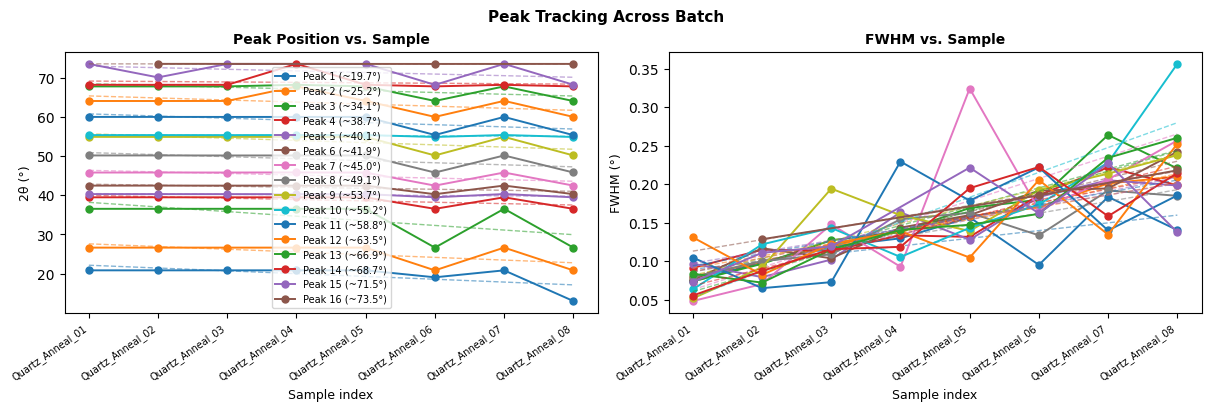

Dashed lines: linear model fits. FWHM slope > 0 confirms systematic grain coarsening.


In [8]:
models = XRDAnalyzer.build_trend_model(peak_table, sample_order)
print(f"Linear trend models for {len(models)} peak families:\n")
display(
    models.style
    .format({
        "Center (°)": "{:.3f}",
        "Position slope (°/sample)": "{:.5f}",
        "Position R²": "{:.4f}",
        "FWHM slope (°/sample)": "{:.5f}",
        "FWHM R²": "{:.4f}",
    })
    .set_caption("Linear trend coefficients — peak position and FWHM vs. sample index")
)
trend_b64_model = HTMLReporter.build_trend_figure(peak_table, sample_order, trend_models=models)
display(Image(data=__import__("base64").b64decode(trend_b64_model)))
print("Dashed lines: linear model fits. FWHM slope > 0 confirms systematic grain coarsening.")


## Step 8: Generate HTML Technical Memo

In [9]:
reporter = HTMLReporter(template_dir=_repo_root / "templates")

t0_report = time.perf_counter()
memo_html = reporter.render(
    summary_table=summary,
    fit_results=fit_results,
    xrd_data=samples,
    metadata={
        "title": "XRD Batch Analysis — Synthetic Quartz Annealing Series",
        "analyst": "Automated Pipeline · Sam Dhole",
        "instrument": "Synthetic data (Cu Kα λ=1.54056 Å, ICDD 00-046-1045)",
        "sample_count": len(samples),
    },
    peak_table=peak_table,
)
report_time = time.perf_counter() - t0_report

output_path = OUTPUT_DIR / "xrd_memo.html"
output_path.write_text(memo_html, encoding="utf-8")

total_time = time.perf_counter() - t0_total
print(f"Memo: {output_path}")
print(f"Size: {len(memo_html) / 1024:.0f} KB\n")
print("=" * 50)
print("  TIMING")
print("=" * 50)
print(f"  Load:        {load_time:.2f}s")
print(f"  Batch fit:   {fit_time:.1f}s  ({len(fit_results)} samples)")
print(f"  Render:      {report_time:.2f}s")
print(f"  Total:       {total_time:.1f}s")
print()
print(f"  Manual researcher equivalent:  ~4 hours")
print(f"  Pipeline:                      {total_time:.0f}s")
print(f"  Speedup:                       ~{int(14400 / total_time):d}×")
print("=" * 50)


Memo: C:\Users\enigm\sciauto\output\reports\xrd_memo.html
Size: 837 KB

  TIMING
  Load:        0.25s
  Batch fit:   13.1s  (8 samples)
  Render:      4.33s
  Total:       22.5s

  Manual researcher equivalent:  ~4 hours
  Pipeline:                      23s
  Speedup:                       ~639×


---

## Summary

The pipeline auto-detects all reflections in each spectrum (no manual peak picking — `xrdfit` requires you to specify peak ranges; `autoXRD` does CNN classification but no per-peak fits), tracks peak families across the batch, and produces a single-file HTML memo a non-specialist process engineer can read.

**Method stack:**
- **Detection:** Difference of Gaussians (after `xrfit`/tgdane) — narrow vs. wide Gaussian smoothing isolates peaks against any baseline shape, MAD-noise-thresholded.
- **Fit:** `lmfit` PseudoVoigt + linear background per ROI (~30 ms/peak).
- **Quality filter:** FWHM, R², amplitude — rejects noise candidates that survived detection.
- **Trend:** peak families clustered post-hoc; position + FWHM tracked vs sample index.
- **Memo:** Jinja2 + matplotlib (base64-embedded), single self-contained HTML file.

---
*Generated by autoxrd · samdhole.github.io*
